### Here, we run scVI to remove batch effect

In [21]:
import os
import tempfile

import matplotlib.pyplot as plt
import scanpy as sc
import scvi
import seaborn as sns
import torch
import gc

In [22]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

Seed set to 0


Last run with scvi-tools version: 1.1.5


In [23]:
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

In [24]:
# has to be raw counts
adata = sc.read_h5ad("COVID_macrophage_harmony.h5ad")
adata

AnnData object with n_obs × n_vars = 56861 × 26571
    obs: 'PatientID', 'Sample type', 'CoVID-19 severity', 'datasets', 'batch', 'celltype', 'majorType', 'sampleID', 'City', 'Age', 'Sex', 'Sample time', 'Sampling day (Days after symptom onset)', 'SARS-CoV-2', 'Single cell sequencing platform', 'BCR single cell sequencing', 'TCR single cell sequencing', 'Outcome', 'Comorbidities', 'COVID-19-related medication and anti-microbials', 'Leukocytes [G/L]', 'Neutrophils [G/L]', 'Lymphocytes [G/L]', 'Unpublished', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden', 'cell_type'
    var: 'gene_ids-0', 'feature_types-0', 'genome-0-0', 'genome-1-0', 'genome-10-0', 'genome-11-0', 'genome-2-0', 'genome-3-0', 'genome-4-0', 'genome-5-0', 'genome-6-0', 'genome-7-0', 'genome-8-0', 'genome-9-0', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersio

In [25]:
### use raw counts
adata.X = adata.layers['counts']

In [26]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2500,
    flavor="seurat_v3",
    batch_key="PatientID",
)

/opt/conda/envs/the-project/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:72: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


In [27]:
scvi.model.SCVI.setup_anndata(
    adata,
    categorical_covariate_keys=[],
    continuous_covariate_keys=["pct_counts_mt"],
    batch_key="PatientID"
)

/opt/conda/envs/the-project/lib/python3.10/site-packages/scvi/data/fields/_base_field.py:64: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [28]:
# n_latent=15 is the best, default 10. 
# dispersion=gene works better
model = scvi.model.SCVI(adata, n_latent=15)
model

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 15, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [33]:
model.view_anndata_setup(adata)

Anndata setup with scvi-tools version 1.1.5.

Setup via `SCVI.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'PatientID',
│   'labels_key': None,
│   'size_factor_key': None,
│   'categorical_covariate_keys': [],
│   'continuous_covariate_keys': ['pct_counts_mt']
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │  24   │
│         n_cells          │ 56861 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   1   │
│         n_labels         │   1   │
│          n_vars          │ 26571 │
└──────────────────────────┴───────┘

                            Data Registry                            
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃            scvi-tools Location            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.X                  │
│         batch         │         adata.obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.obsm['_scvi_extra_continuous_covs'] │
│        labels         │         adata.obs['_scvi_labels']         │
└───────────────────────┴───────────────────────────────────────────┘

                    batch State Registry                     
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['PatientID'] │    C51     │          0          │
│                        │    C52     │          1          │
│                        │    C100    │          2          │
│                        │    C141    │          3          │
│                        │    C142    │          4          │
│                        │    C143    │          5          │
│                        │    C144    │          6          │
│                        │    C145    │          7          │
│                        │    C146    │          8          │
│                        │    C148    │          9          │
│                        │    C149    │         10          │
│                        │    C152    │         11          │
│                        │   P-M074   │         12          │
│                        │   P-M075   │         13          │
│                        │   P-M076   │         14          │
│                        │   P-S006   │         15          │
│                        │   P-S008   │         16          │
│                        │   P-S009   │         17          │
│                        │   P-S085   │         18          │
│                        │   P-S086   │         19          │
│                        │   P-S087   │         20          │
│                        │   P-S088   │         21          │
│                        │   P-S089   │         22          │
│                        │   P-S090   │         23          │
└────────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

 extra_continuous_covs State  
           Registry           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['pct_counts_mt'] │
└────────────────────────────┘

In [34]:
model.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/opt/conda/envs/the-project/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 1/141:   0% 0/141 [00:00<?, ?it/s]

/opt/conda/envs/the-project/lib/python3.10/site-packages/scvi/module/_vae.py:460: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)
/opt/conda/envs/the-project/lib/python3.10/site-packages/scvi/module/_vae.py:460: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)


Epoch 2/141:   1% 1/141 [03:05<7:13:11, 185.65s/it, v_num=1, train_loss_step=4.76e+3, train_loss_epoch=4.81e+3]

/opt/conda/envs/the-project/lib/python3.10/site-packages/scvi/module/_vae.py:460: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)
/opt/conda/envs/the-project/lib/python3.10/site-packages/scvi/module/_vae.py:460: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)


...

Epoch 141/141:  99% 140/141 [4:38:23<01:47, 107.93s/it, v_num=1, train_loss_step=4.2e+3, train_loss_epoch=4.16e+3]

/opt/conda/envs/the-project/lib/python3.10/site-packages/scvi/module/_vae.py:460: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)
/opt/conda/envs/the-project/lib/python3.10/site-packages/scvi/module/_vae.py:460: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)


Epoch 141/141: 100% 141/141 [4:39:57<00:00, 103.64s/it, v_num=1, train_loss_step=4.18e+3, train_loss_epoch=4.16e+3]

`Trainer.fit` stopped: `max_epochs=141` reached.


Epoch 141/141: 100% 141/141 [4:39:57<00:00, 119.13s/it, v_num=1, train_loss_step=4.18e+3, train_loss_epoch=4.16e+3]


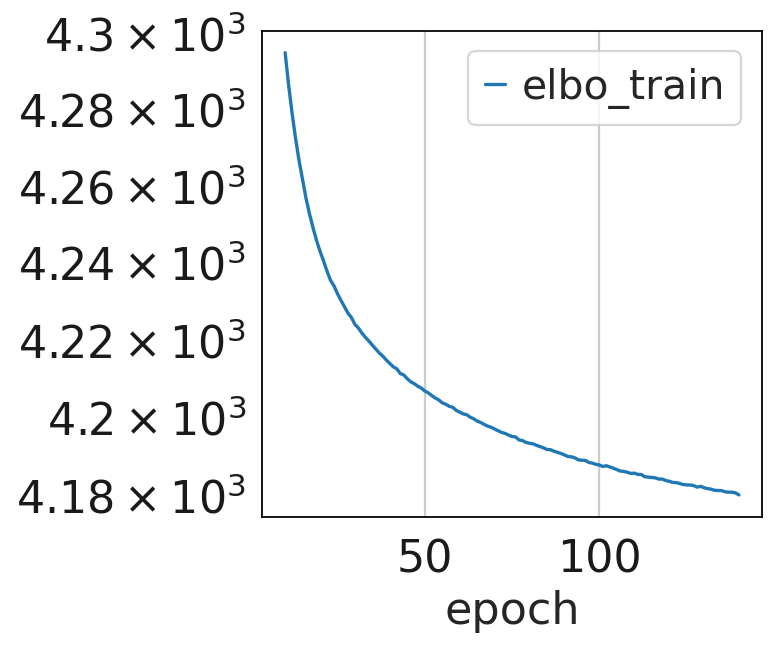

In [35]:
# Ensure convergence
train_test_results = model.history["elbo_train"]
# train_test_results["elbo_validation"] = model.history["elbo_validation"]
train_test_results.iloc[10:].plot(logy=True)  # exclude first 10 epochs
plt.show()

In [36]:
model.save("scvi_COVID_model_15", overwrite=True)

In [29]:
model = scvi.model.SCVI.load("scvi_COVID_model_15/", adata=adata)

INFO     File scvi_COVID_model_15/model.pt already downloaded                                                      


/opt/conda/envs/the-project/lib/python3.10/site-packages/scvi/data/fields/_base_field.py:64: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [30]:
SCVI_LATENT_KEY = "X_scVI"

latent = model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY] = latent
latent.shape

(56861, 15)

In [31]:
denoised = model.get_normalized_expression(adata, library_size=1e4)
denoised

,AL627309.1,AL627309.4,AL732372.1,AL669831.2,AL669831.5,FAM87B,LINC00115,FAM41C,AL645608.7,AL645608.3,...,AL592183.1,AC007325.1,AC007325.4,AC007325.2,AL354822.1,AC023491.2,AC004556.1,AC233755.2,AC233755.1,AC240274.1
AAACCTGAGGAGTACC-1-0-0,0.000760,0.000753,0.000113,0.000459,0.079521,0.001343,0.013760,0.019564,0.000181,0.000259,...,0.138652,0.000481,0.120113,0.000402,0.032149,0.000314,0.000531,0.000529,0.000369,0.099638
AAACGGGCAGCCAATT-1-0-0,0.003608,0.000164,0.000584,0.000214,0.061837,0.001138,0.015364,0.034270,0.000178,0.000268,...,0.015245,0.000975,0.053610,0.003680,0.009618,0.000543,0.002028,0.000682,0.000103,0.042790
AAACGGGGTCCATGAT-1-0-0,0.000291,0.001354,0.000135,0.000235,0.040876,0.003774,0.028433,0.020978,0.000168,0.000241,...,0.046695,0.000322,0.117793,0.000115,0.025363,0.000093,0.000659,0.001018,0.000211,0.021607
AAACGGGGTCTCTCTG-1-0-0,0.002078,0.000296,0.000695,0.000349,0.151985,0.000713,0.028942,0.066910,0.000245,0.000621,...,0.045340,0.003079,0.092604,0.003007,0.018866,0.001416,0.003252,0.000631,0.000124,0.107433
AAACGGGGTGCGAAAC-1-0-0,0.000638,0.000447,0.000184,0.000191,0.057195,0.000790,0.034882,0.018567,0.000079,0.000243,...,0.035994,0.000683,0.028707,0.000371,0.004368,0.000069,0.003612,0.001633,0.000355,0.058644
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCCTTCTTCGAGGCAA-224-1,0.000682,0.018132,0.000046,0.006349,0.229144,0.000582,0.088046,0.398090,0.000079,0.012289,...,0.012275,0.010692,0.004736,0.000110,0.057513,0.004825,0.006760,0.000434,0.000154,0.000714
TGAATGCCAGATCCTA-224-1,0.000361,0.025268,0.000065,0.005591,0.374641,0.008409,0.090459,0.355612,0.000168,0.009486,...,0.061496,0.001868,0.003901,0.000228,0.118038,0.005036,0.010312,0.000434,0.000251,0.001315
TTACAGGGTATGGAAT-224-1,0.001939,0.051517,0.000474,0.005570,0.468454,0.010682,0.161908,0.205720,0.000248,0.022379,...,0.047679,0.006925,0.007058,0.000287,0.157780,0.009092,0.003054,0.001958,0.001367,0.002969
TTACCGCAGAGAGGGC-224-1,0.000166,0.069224,0.000033,0.002702,0.245504,0.000487,0.157720,0.133118,0.000060,0.005266,...,0.185763,0.019301,0.006006,0.000169,0.011481,0.009880,0.039633,0.000240,0.000029,0.000652


In [32]:
SCVI_NORMALIZED_KEY = "scvi_normalized"

adata.layers[SCVI_NORMALIZED_KEY] = model.get_normalized_expression(library_size=1e4)

In [33]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(adata, n_neighbors=15, use_rep=SCVI_LATENT_KEY)
adata

AnnData object with n_obs × n_vars = 56861 × 26571
    obs: 'PatientID', 'Sample type', 'CoVID-19 severity', 'datasets', 'batch', 'celltype', 'majorType', 'sampleID', 'City', 'Age', 'Sex', 'Sample time', 'Sampling day (Days after symptom onset)', 'SARS-CoV-2', 'Single cell sequencing platform', 'BCR single cell sequencing', 'TCR single cell sequencing', 'Outcome', 'Comorbidities', 'COVID-19-related medication and anti-microbials', 'Leukocytes [G/L]', 'Neutrophils [G/L]', 'Lymphocytes [G/L]', 'Unpublished', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden', 'cell_type', '_scvi_batch', '_scvi_labels'
    var: 'gene_ids-0', 'feature_types-0', 'genome-0-0', 'genome-1-0', 'genome-10-0', 'genome-11-0', 'genome-2-0', 'genome-3-0', 'genome-4-0', 'genome-5-0', 'genome-6-0', 'genome-7-0', 'genome-8-0', 'genome-9-0', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly

In [34]:
# neighbors were already computed using scVI
SCVI_CLUSTERS_KEY = "leiden_scVI"
sc.tl.leiden(adata, key_added=SCVI_CLUSTERS_KEY, resolution=1)

In [35]:
adata.obs.leiden_scVI

AAACCTGAGGAGTACC-1-0-0     7
AAACGGGCAGCCAATT-1-0-0    16
AAACGGGGTCCATGAT-1-0-0     7
AAACGGGGTCTCTCTG-1-0-0    16
AAACGGGGTGCGAAAC-1-0-0     1
                          ..
TCCTTCTTCGAGGCAA-224-1     4
TGAATGCCAGATCCTA-224-1    18
TTACAGGGTATGGAAT-224-1     9
TTACCGCAGAGAGGGC-224-1     3
TTACTGTGTCGTACAT-224-1     8
Name: leiden_scVI, Length: 56861, dtype: category
Categories (21, object): ['0', '1', '2', '3', ..., '17', '18', '19', '20']

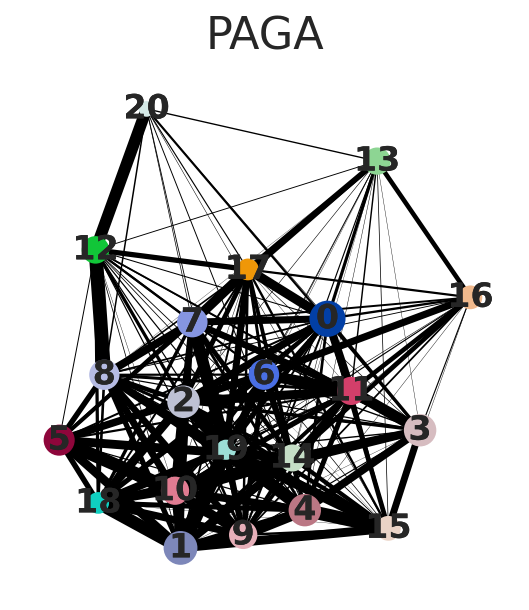

AnnData object with n_obs × n_vars = 56861 × 26571
    obs: 'PatientID', 'Sample type', 'CoVID-19 severity', 'datasets', 'batch', 'celltype', 'majorType', 'sampleID', 'City', 'Age', 'Sex', 'Sample time', 'Sampling day (Days after symptom onset)', 'SARS-CoV-2', 'Single cell sequencing platform', 'BCR single cell sequencing', 'TCR single cell sequencing', 'Outcome', 'Comorbidities', 'COVID-19-related medication and anti-microbials', 'Leukocytes [G/L]', 'Neutrophils [G/L]', 'Lymphocytes [G/L]', 'Unpublished', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden', 'cell_type', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
    var: 'gene_ids-0', 'feature_types-0', 'genome-0-0', 'genome-1-0', 'genome-10-0', 'genome-11-0', 'genome-2-0', 'genome-3-0', 'genome-4-0', 'genome-5-0', 'genome-6-0', 'genome-7-0', 'genome-8-0', 'genome-9-0', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_c

In [36]:
sc.tl.paga(adata, groups=SCVI_CLUSTERS_KEY)
sc.set_figure_params(fontsize=20)
sc.pl.paga(adata, fontsize=15, frameon=False, title='PAGA', fontoutline=0, save="_COVID.svg")
adata

In [37]:
# sc.tl.umap(ndata)
sc.tl.umap(adata, init_pos='paga')
adata

AnnData object with n_obs × n_vars = 56861 × 26571
    obs: 'PatientID', 'Sample type', 'CoVID-19 severity', 'datasets', 'batch', 'celltype', 'majorType', 'sampleID', 'City', 'Age', 'Sex', 'Sample time', 'Sampling day (Days after symptom onset)', 'SARS-CoV-2', 'Single cell sequencing platform', 'BCR single cell sequencing', 'TCR single cell sequencing', 'Outcome', 'Comorbidities', 'COVID-19-related medication and anti-microbials', 'Leukocytes [G/L]', 'Neutrophils [G/L]', 'Lymphocytes [G/L]', 'Unpublished', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'leiden', 'cell_type', '_scvi_batch', '_scvi_labels', 'leiden_scVI'
    var: 'gene_ids-0', 'feature_types-0', 'genome-0-0', 'genome-1-0', 'genome-10-0', 'genome-11-0', 'genome-2-0', 'genome-3-0', 'genome-4-0', 'genome-5-0', 'genome-6-0', 'genome-7-0', 'genome-8-0', 'genome-9-0', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_c

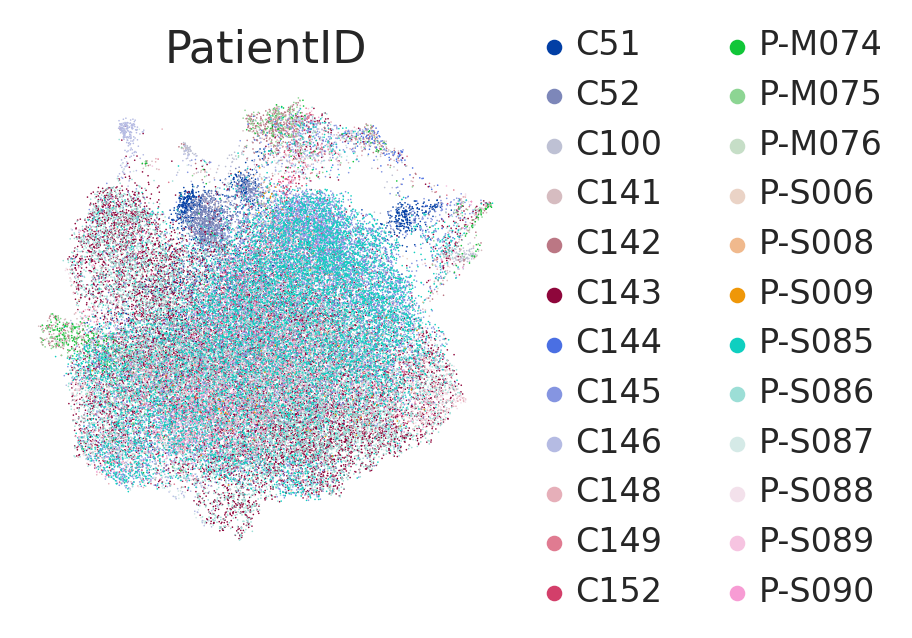

In [38]:
sc.pl.umap(adata, color='PatientID', 
           frameon=False, legend_fontsize=15, legend_fontoutline=1, save="_COVID_UMAP_PatientID.png")

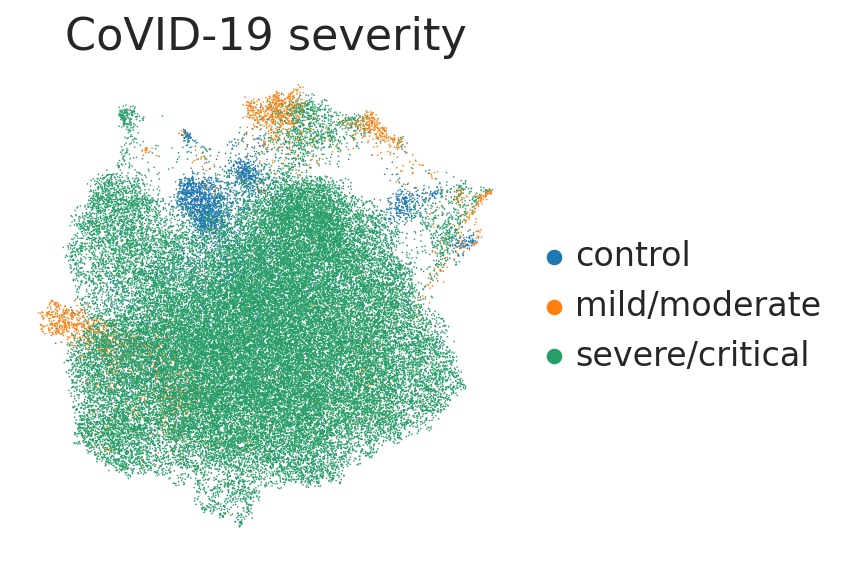

In [39]:
sc.pl.umap(adata, color='CoVID-19 severity',
           frameon=False, legend_fontsize=15, legend_fontoutline=1, save="_COVID_UMAP_Severity.png")

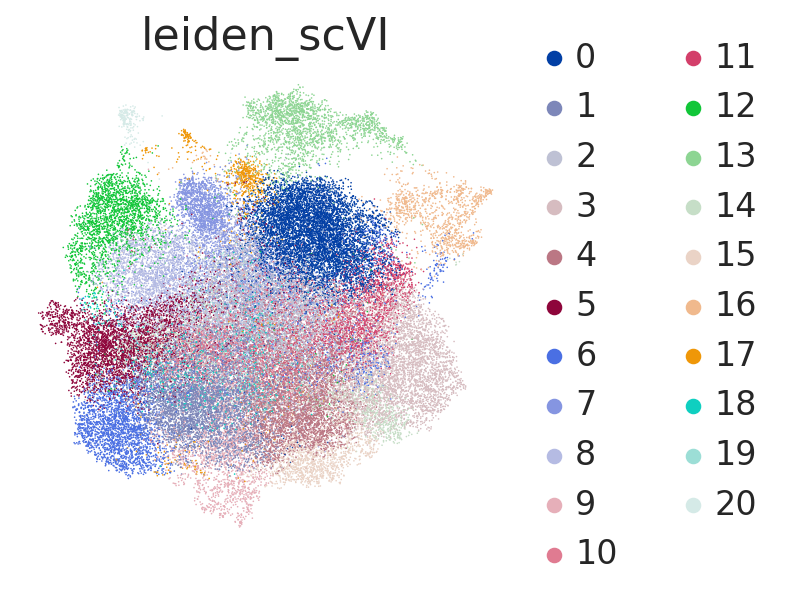

In [40]:
sc.pl.umap(adata, color=SCVI_CLUSTERS_KEY, frameon=False, legend_fontsize=15, save="_COVID_cluster.png")

In [41]:
# normalized data by library size
adata.write("COVID_macrophage_scVI.h5ad")

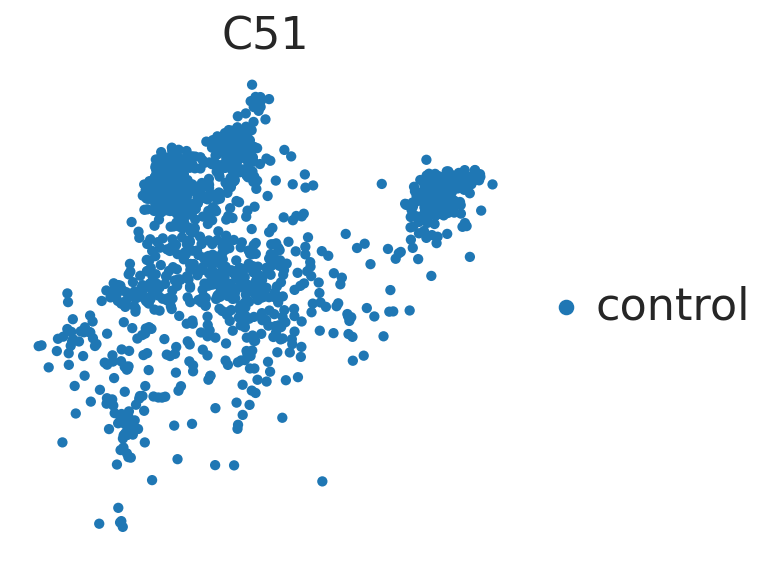

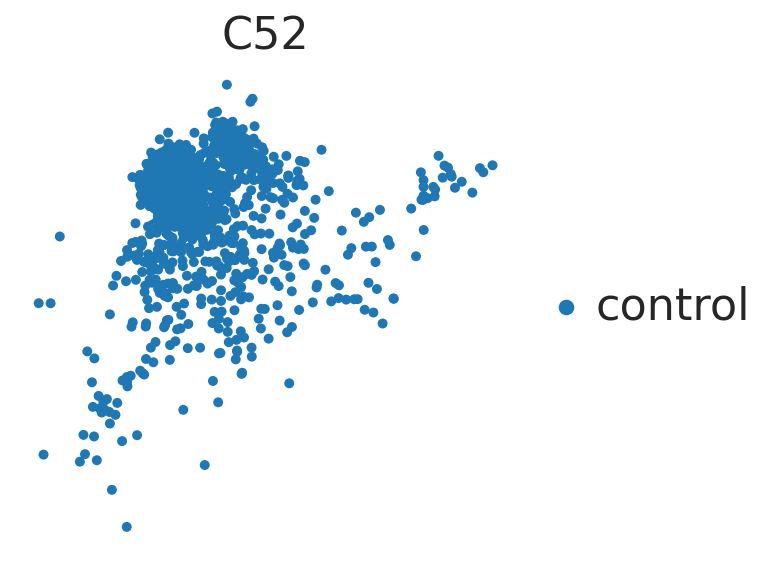

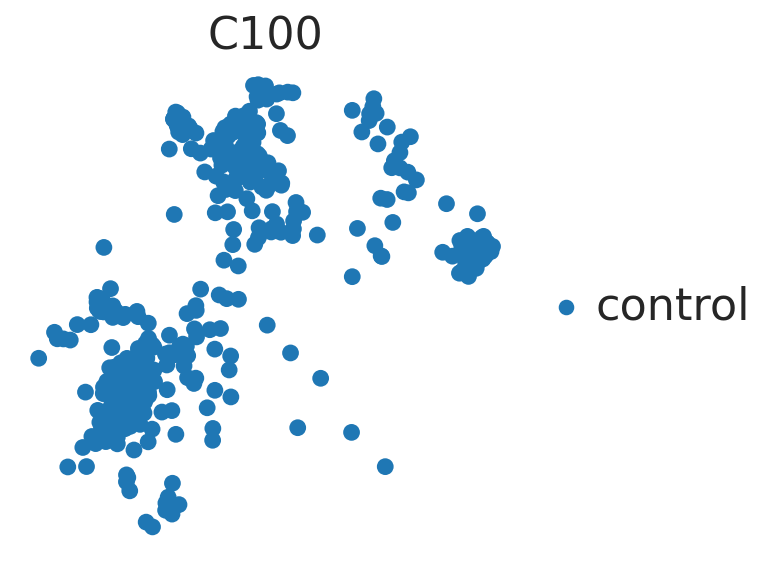

In [42]:
for i in ['C51','C52','C100']:
    sc.pl.umap(adata[adata.obs.PatientID==i], color='CoVID-19 severity', frameon=False, legend_fontsize=20, legend_fontoutline=1, title=i, save=f"_{i}_INSS.svg")

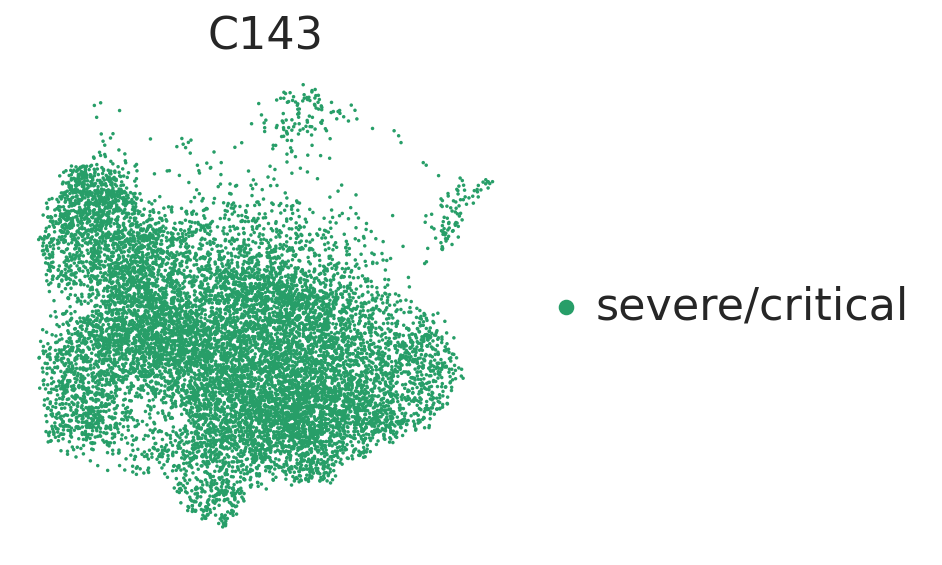

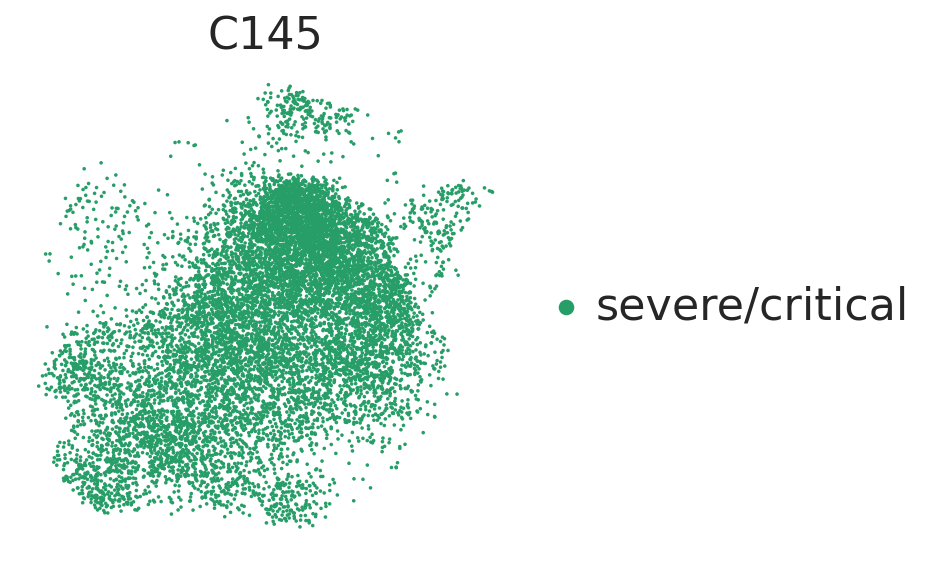

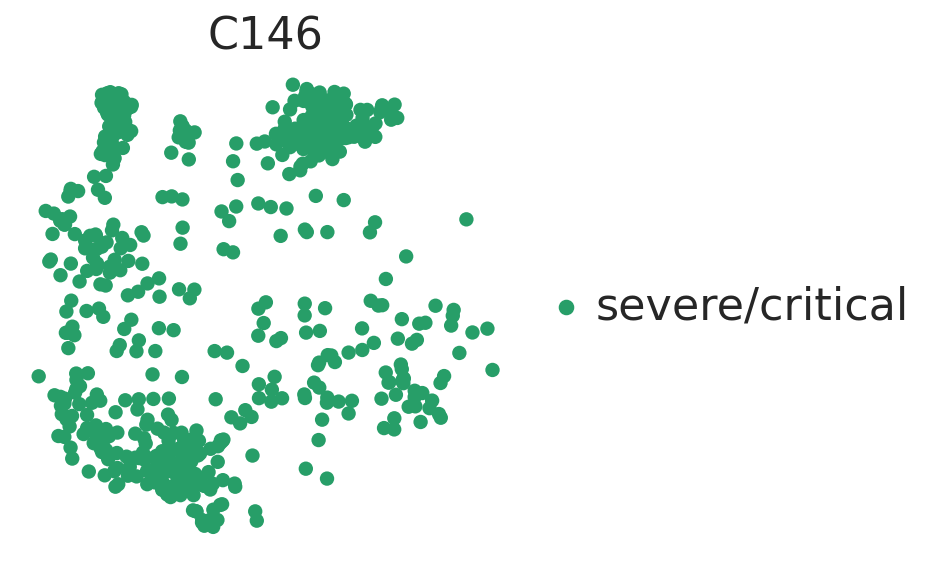

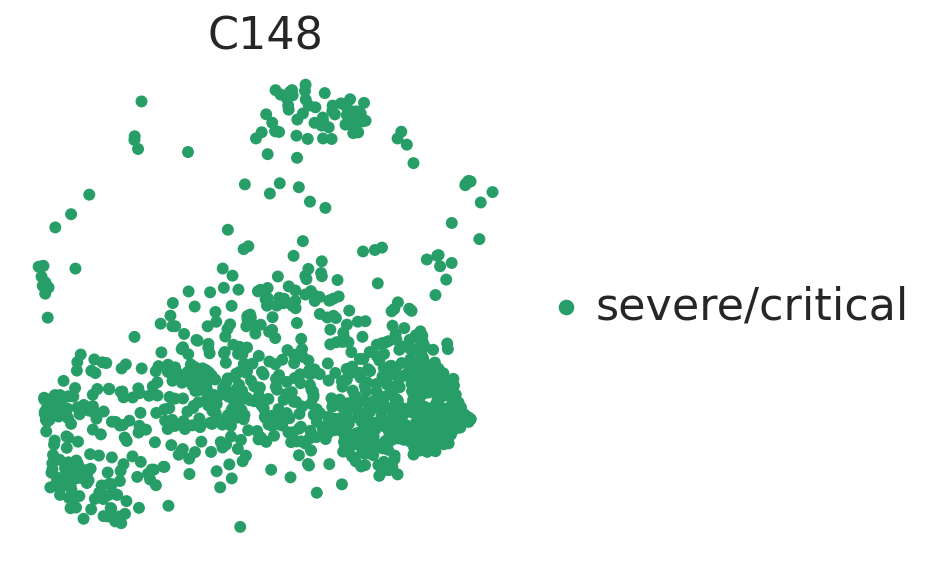

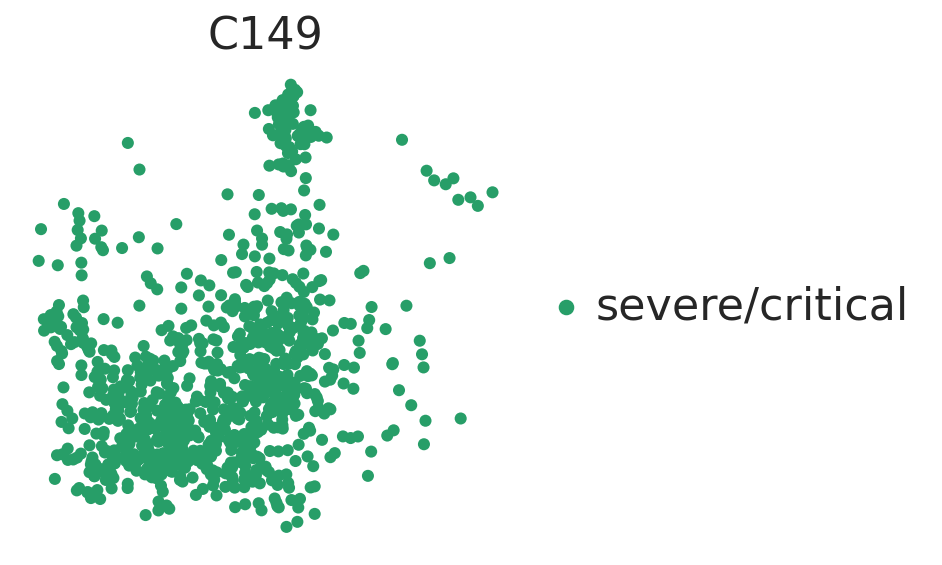

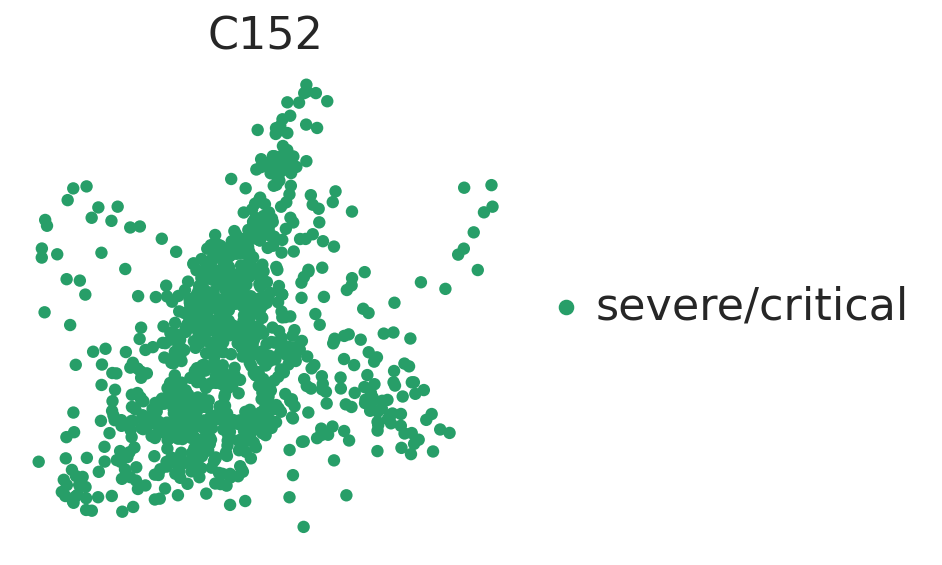

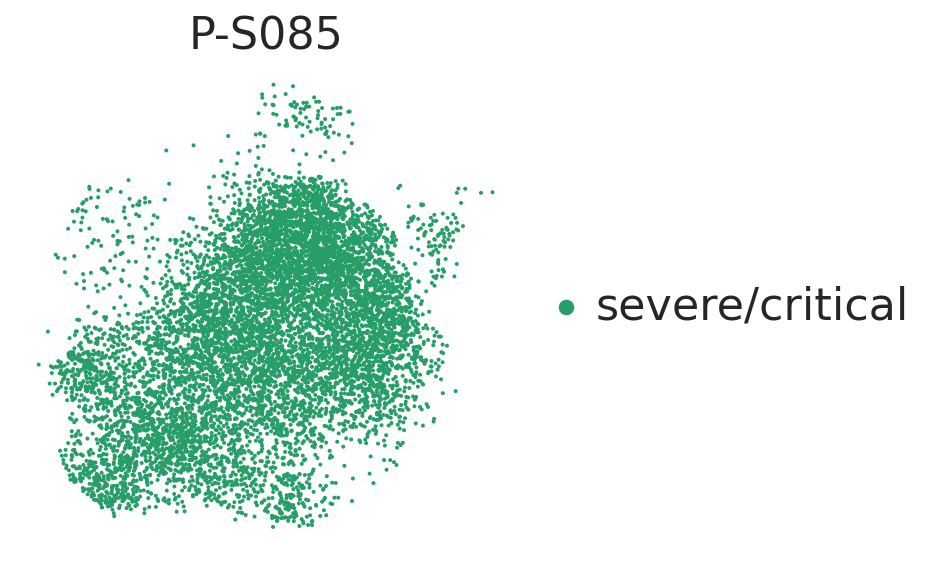

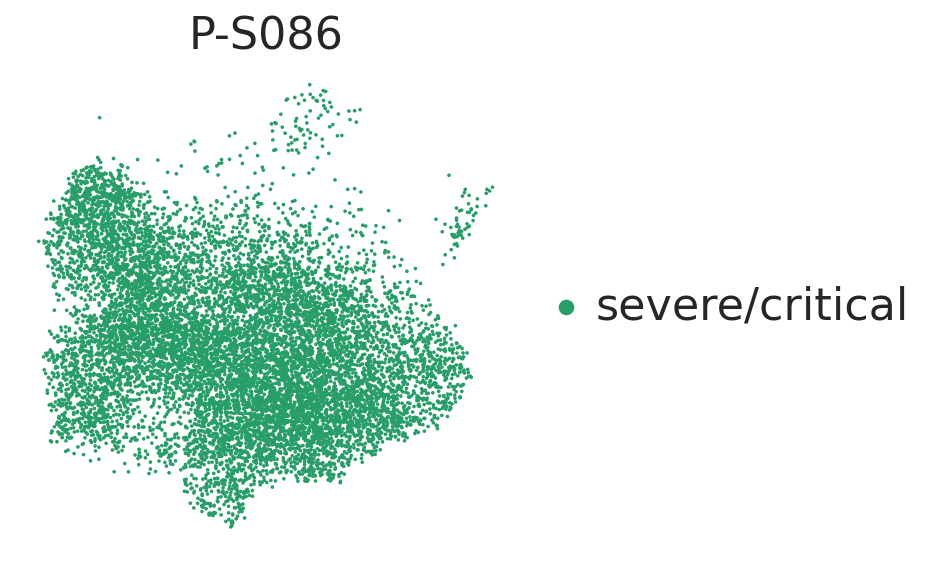

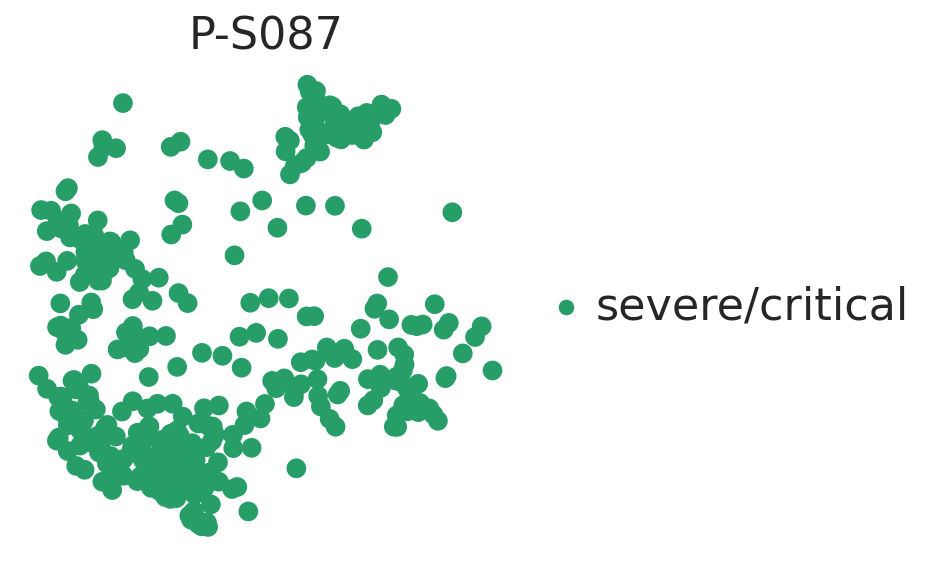

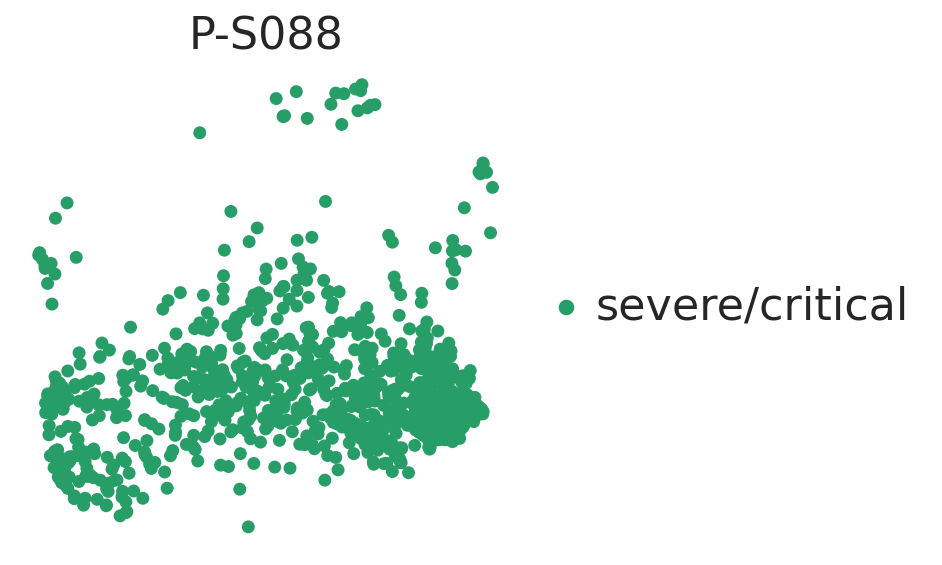

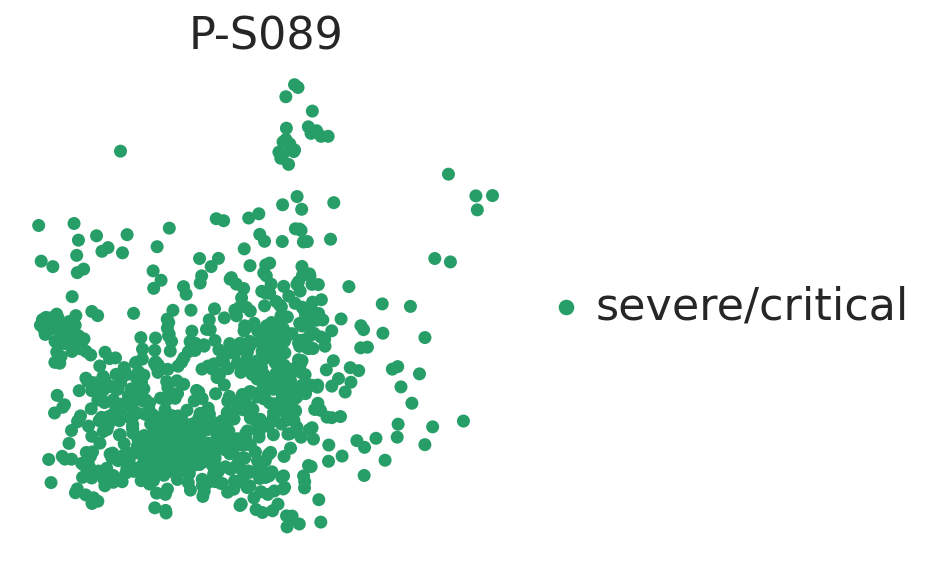

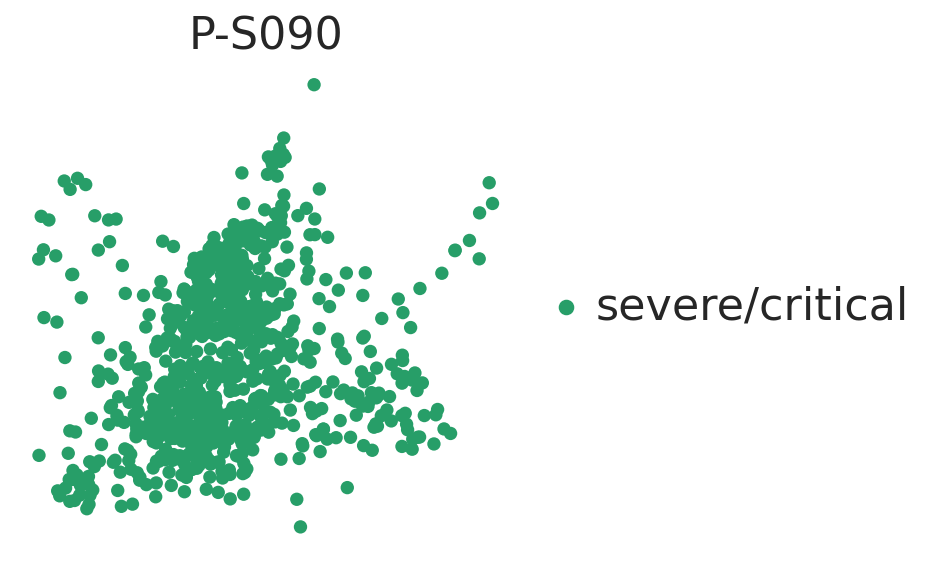

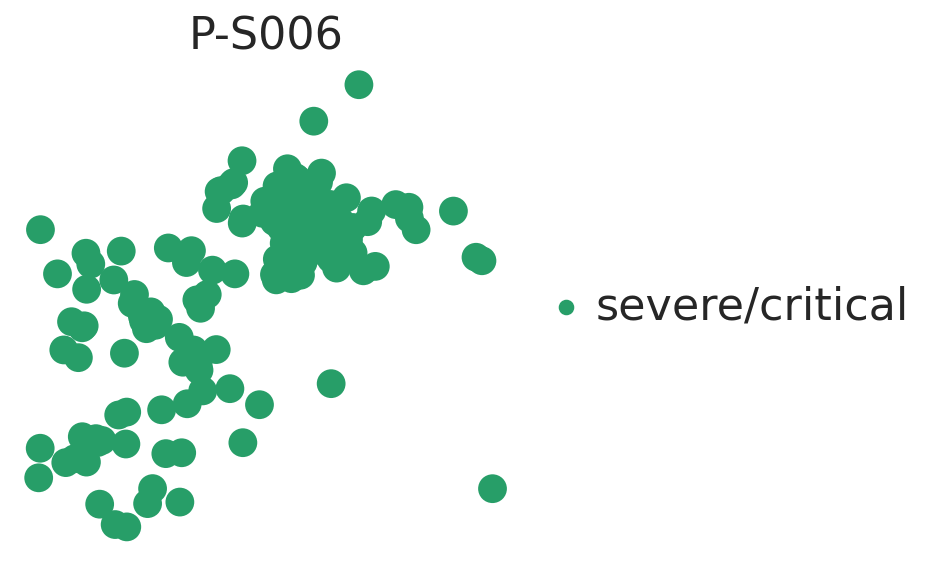

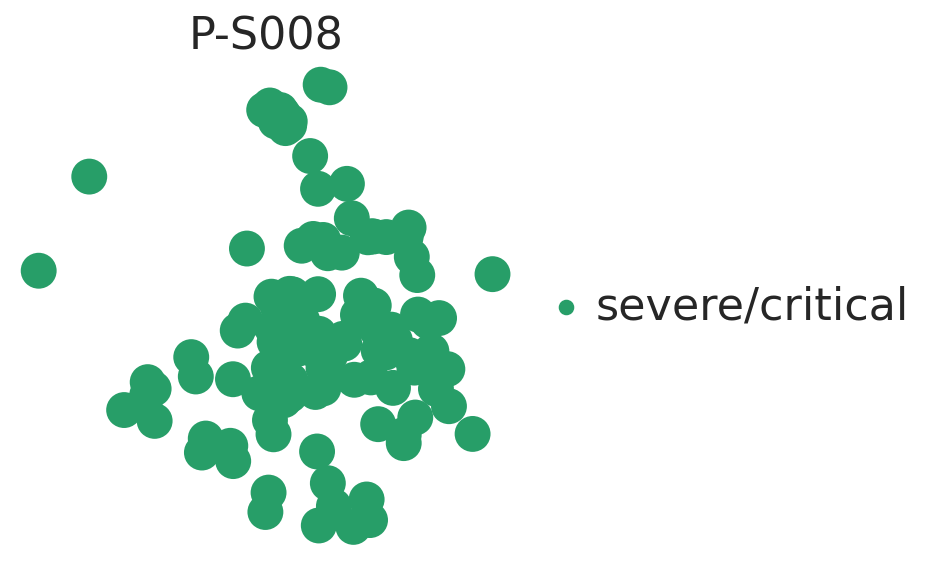

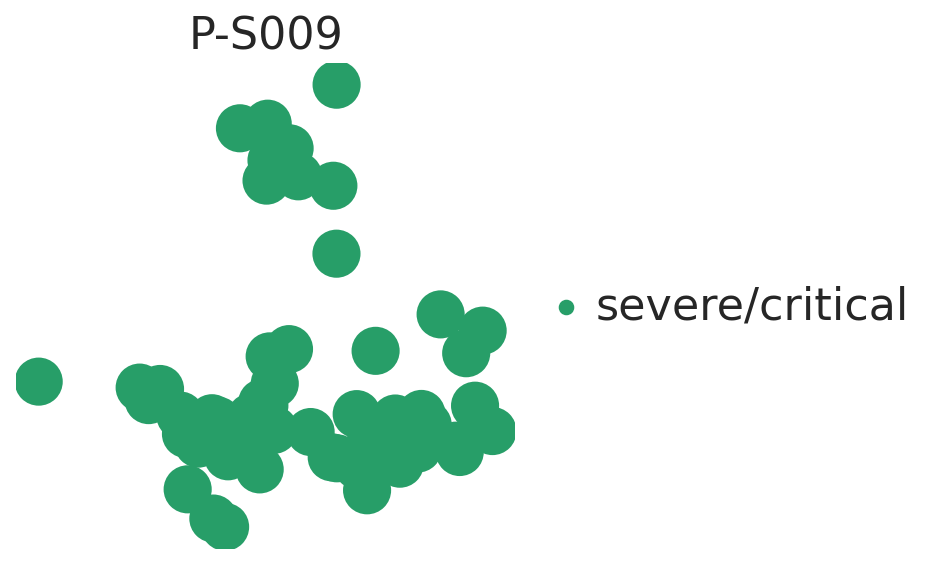

In [43]:
for i in ['C143','C145','C146','C148','C149','C152','P-S085','P-S086','P-S087','P-S088','P-S089','P-S090','P-S006','P-S008','P-S009']:
    sc.pl.umap(adata[adata.obs.PatientID==i], color='CoVID-19 severity', frameon=False, legend_fontsize=20, legend_fontoutline=1, title=i, save=f"_{i}_.png")

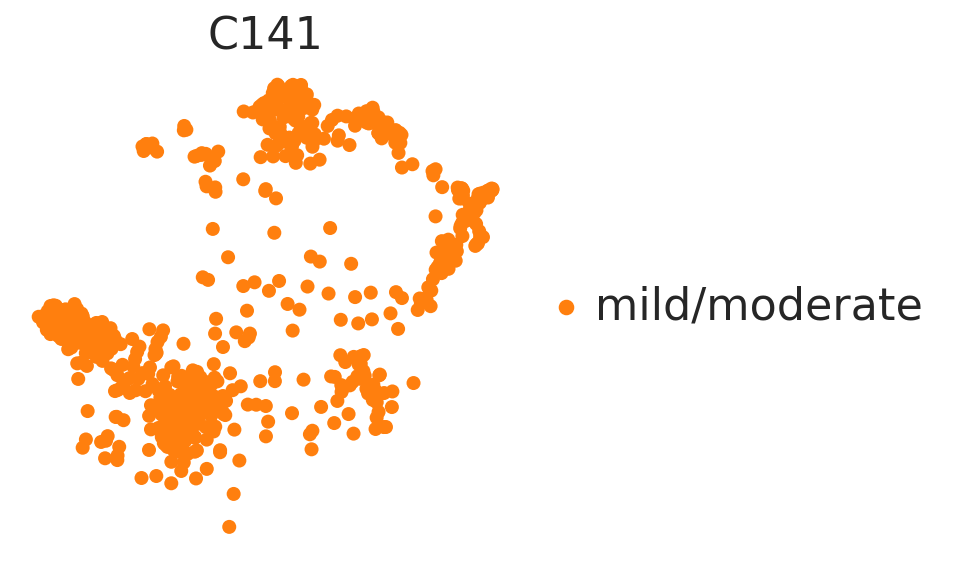

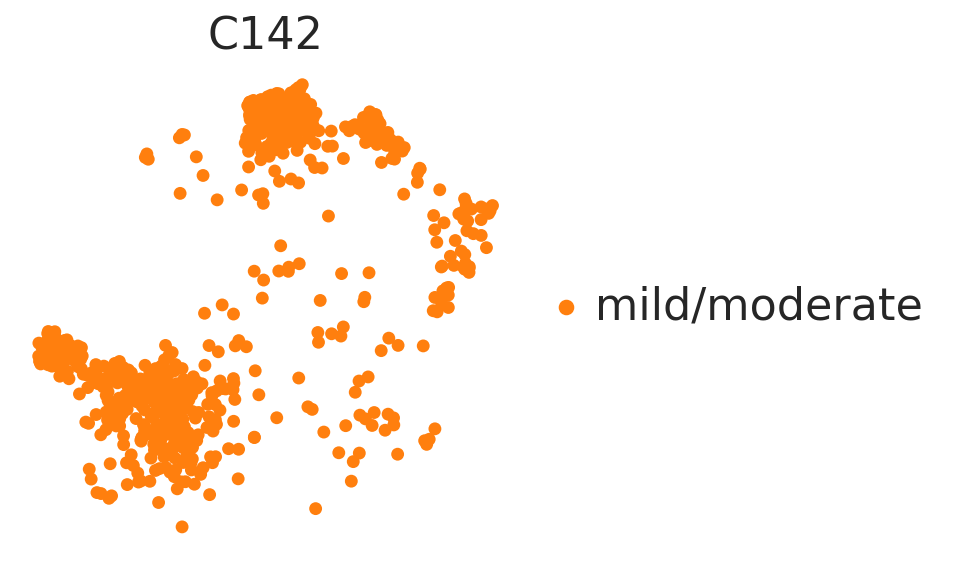

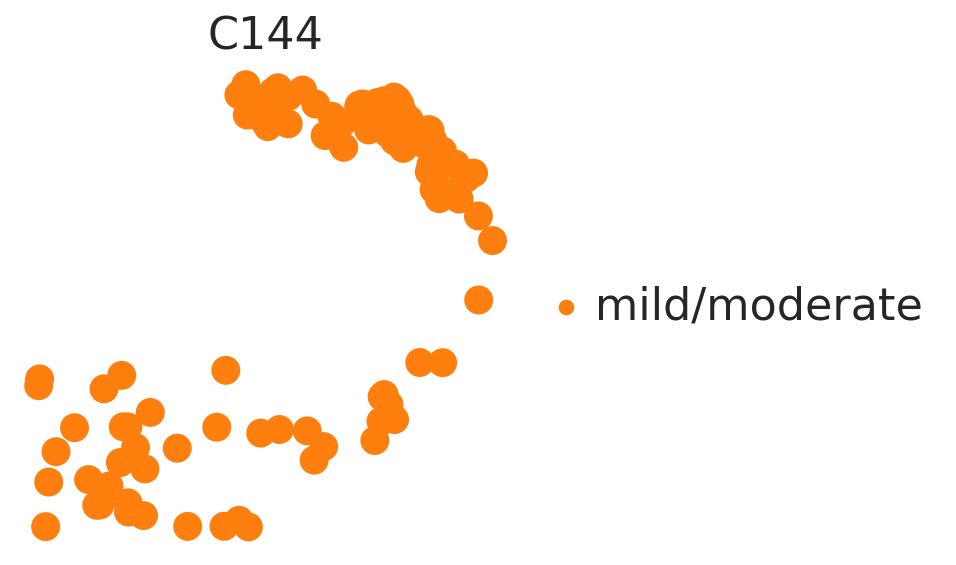

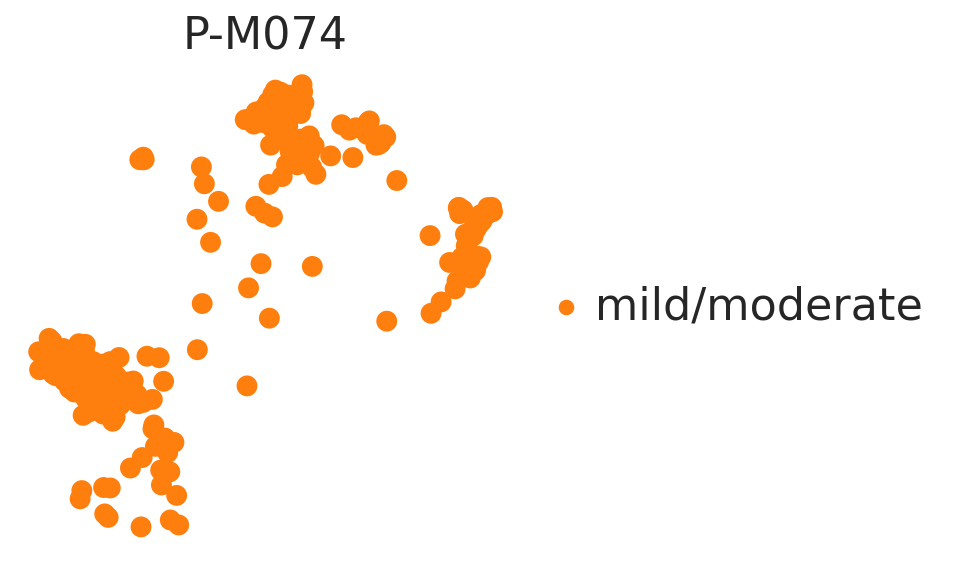

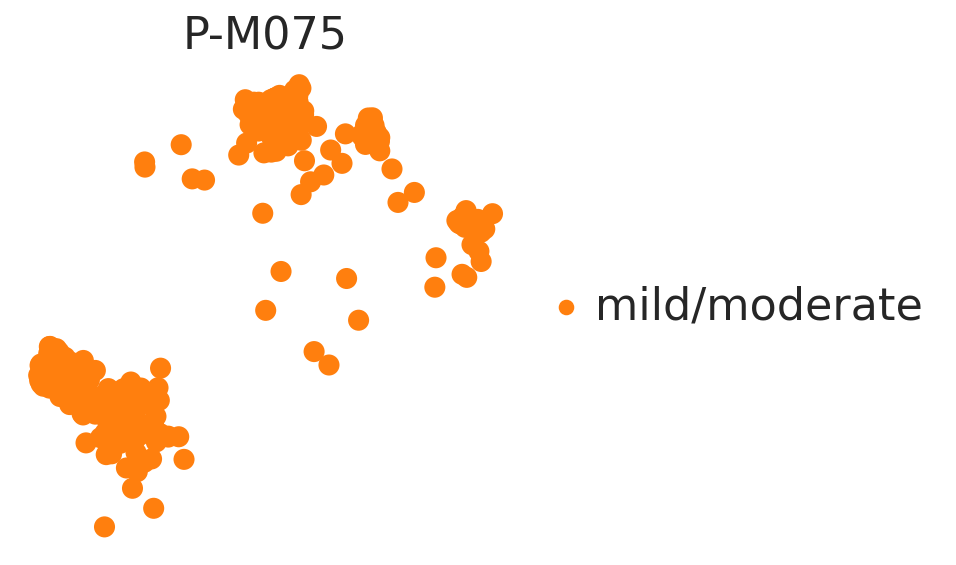

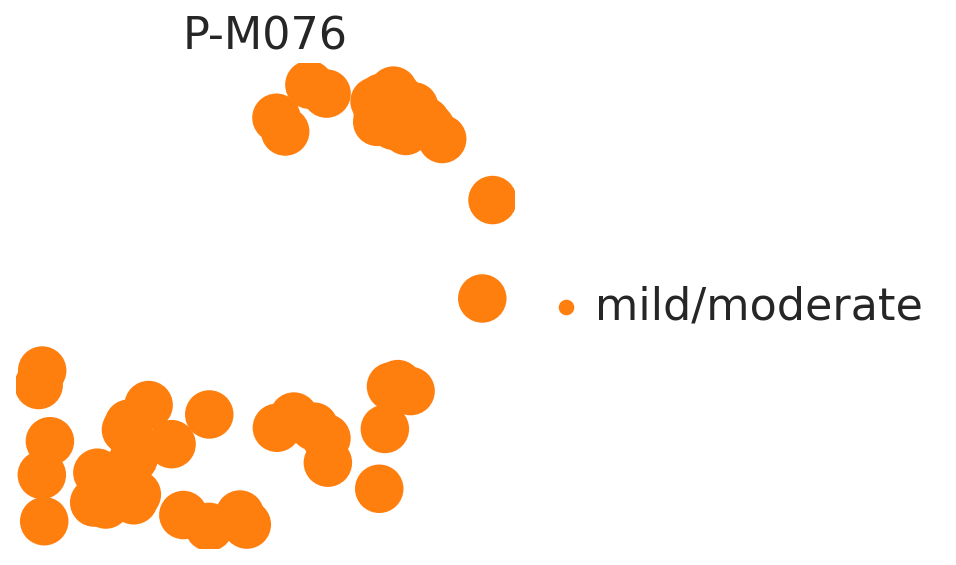

In [44]:
for i in ['C141','C142','C144','P-M074','P-M075','P-M076']:
    sc.pl.umap(adata[adata.obs.PatientID==i], color='CoVID-19 severity', frameon=False, legend_fontsize=20, legend_fontoutline=1, title=i, save=f"_{i}_.png")